# **HeartAttack**

 With HadHeartAttack as the prediction variable, the task would involve using other features in the dataset to predict whether a patient has experienced a heart attack. This could be approached as a binary classification problem, where the model learns patterns from the other variables to predict the likelihood of HadHeartAttack (0 for no, 1 for yes).


Heart disease is one of the leading causes of mortality worldwide, with heart attacks being a primary manifestation. Early detection and intervention can significantly reduce the risk and improve patient outcomes. In this project, we aim to develop a predictive model that leverages patient demographic, health, and lifestyle information to determine the likelihood of a heart attack occurrence. By analyzing this data, healthcare providers may gain insights into high-risk patients, enabling proactive measures and better allocation of medical resources.

The objective is to predict whether a patient has had a heart attack (binary outcome: HadHeartAttack) based on a range of features, including medical history, lifestyle habits, and demographic details. This model could serve as an assistive tool in clinical decision-making and help in implementing preventive healthcare strategies.

## **load and inspect the data**

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Dataset/Patients Data ( Used for Heart Disease Prediction ).csv", encoding='latin1')
df

,ÿPatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,Never used e-cigarettes in my entire life,1,"White only, Non-Hispanic",0,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
1,2,Alabama,Female,Very good,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received Tdap",0,0
2,3,Alabama,Male,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",1,0,0,0,"Yes, received tetanus shot but not sure what type",0,0
3,4,Alabama,Male,Very good,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received tetanus shot but not sure what type",0,0
4,5,Alabama,Female,Good,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,Never used e-cigarettes in my entire life,1,"Black only, Non-Hispanic",0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237625,237626,Puerto Rico,Female,Good,Age 60 to 64,1.57,90.720001,36.580002,0,0,...,Not at all (right now),0,Hispanic,0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
237626,237627,Puerto Rico,Female,Good,Age 55 to 59,1.70,72.570000,25.059999,0,1,...,Not at all (right now),0,Hispanic,0,1,0,0,"Yes, received Tdap",0,0
237627,237628,Puerto Rico,Male,Fair,Age 45 to 49,1.75,70.309998,22.889999,1,1,...,Not at all (right now),1,Hispanic,0,1,1,1,"Yes, received Tdap",1,0
237628,237629,Puerto Rico,Female,Very good,Age 25 to 29,1.57,46.720001,18.840000,0,0,...,Never used e-cigarettes in my entire life,0,Hispanic,0,1,0,0,"No, did not receive any tetanus shot in the pa...",0,1


In [ ]:
df.head()

,ÿPatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,Never used e-cigarettes in my entire life,1,"White only, Non-Hispanic",0,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
1,2,Alabama,Female,Very good,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received Tdap",0,0
2,3,Alabama,Male,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",1,0,0,0,"Yes, received tetanus shot but not sure what type",0,0
3,4,Alabama,Male,Very good,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received tetanus shot but not sure what type",0,0
4,5,Alabama,Female,Good,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,Never used e-cigarettes in my entire life,1,"Black only, Non-Hispanic",0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0


In [ ]:
df.tail()

,ÿPatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
237625,237626,Puerto Rico,Female,Good,Age 60 to 64,1.57,90.720001,36.580002,0,0,...,Not at all (right now),0,Hispanic,0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
237626,237627,Puerto Rico,Female,Good,Age 55 to 59,1.70,72.570000,25.059999,0,1,...,Not at all (right now),0,Hispanic,0,1,0,0,"Yes, received Tdap",0,0
237627,237628,Puerto Rico,Male,Fair,Age 45 to 49,1.75,70.309998,22.889999,1,1,...,Not at all (right now),1,Hispanic,0,1,1,1,"Yes, received Tdap",1,0
237628,237629,Puerto Rico,Female,Very good,Age 25 to 29,1.57,46.720001,18.840000,0,0,...,Never used e-cigarettes in my entire life,0,Hispanic,0,1,0,0,"No, did not receive any tetanus shot in the pa...",0,1
237629,237630,Puerto Rico,Female,Good,Age 30 to 34,1.60,83.010002,32.419998,0,0,...,Never used e-cigarettes in my entire life,1,Hispanic,0,1,0,0,"No, did not receive any tetanus shot in the pa...",0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ÿPatientID                 237630 non-null  int64  
 1   State                      237630 non-null  object 
 2   Sex                        237630 non-null  object 
 3   GeneralHealth              237630 non-null  object 
 4   AgeCategory                237630 non-null  object 
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

## **cleaning**

In [ ]:
df.isnull().sum()

,0
ÿPatientID,0
State,0
Sex,0
GeneralHealth,0
AgeCategory,0
HeightInMeters,0
WeightInKilograms,0
BMI,0
HadHeartAttack,0
HadAngina,0


In [ ]:
df.shape

(237630, 35)

In [ ]:
df.duplicated().sum()

np.int64(0)

## **visualization**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

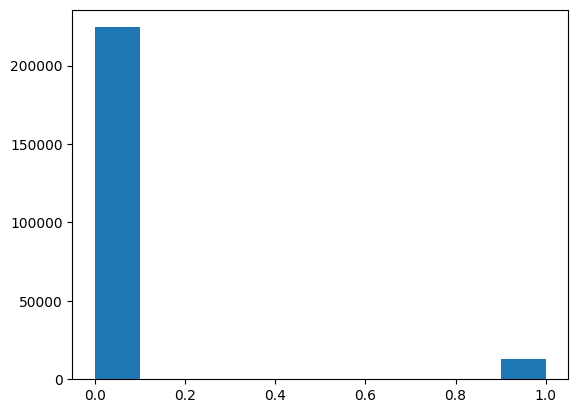

In [ ]:
plt.hist(df["HadHeartAttack"])
plt.show()

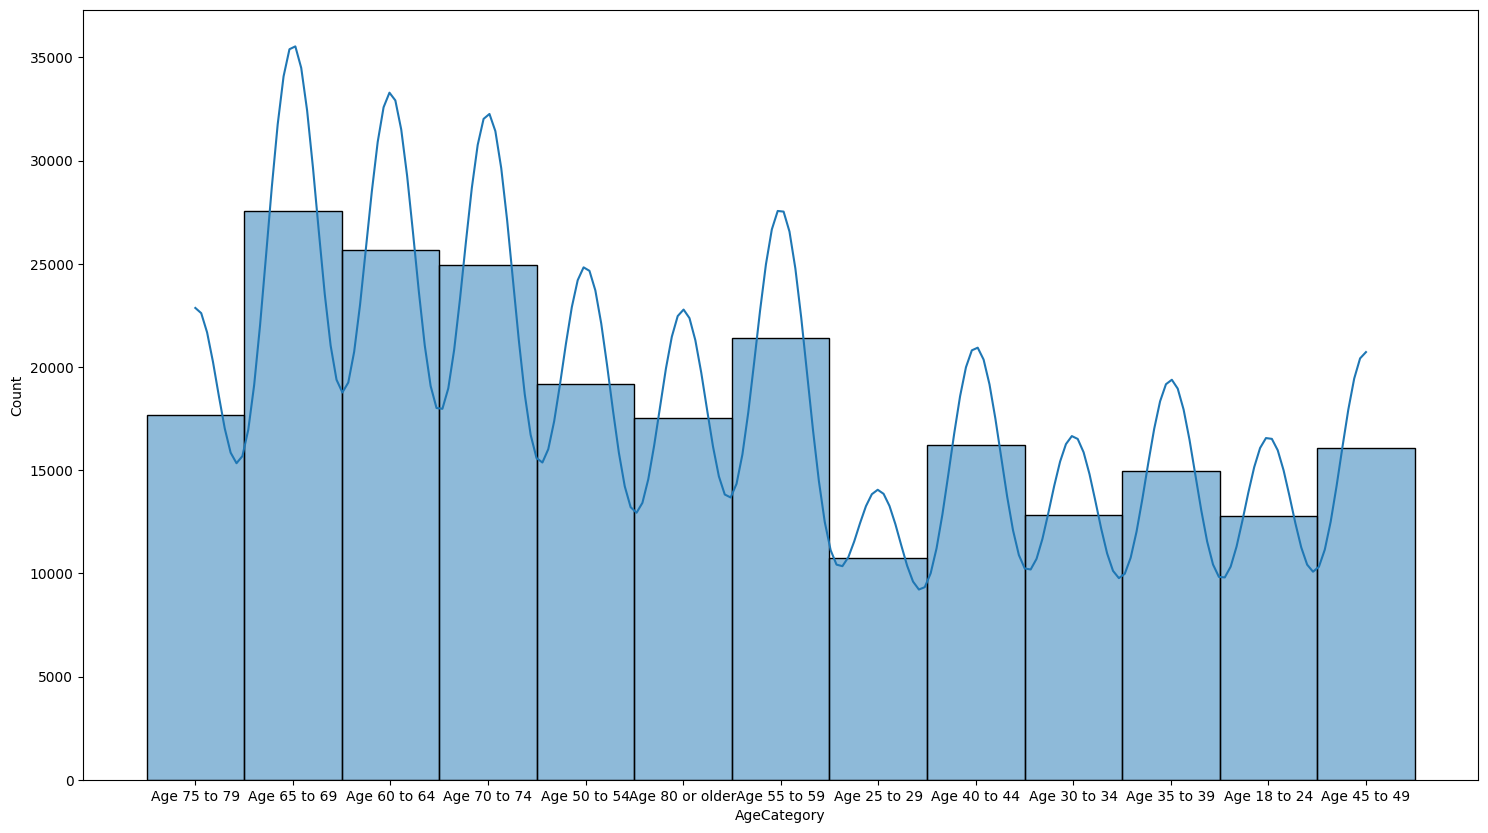

In [ ]:
plt.figure(figsize=(18,10))
sns.histplot(df['AgeCategory'], kde=True)
plt.show()

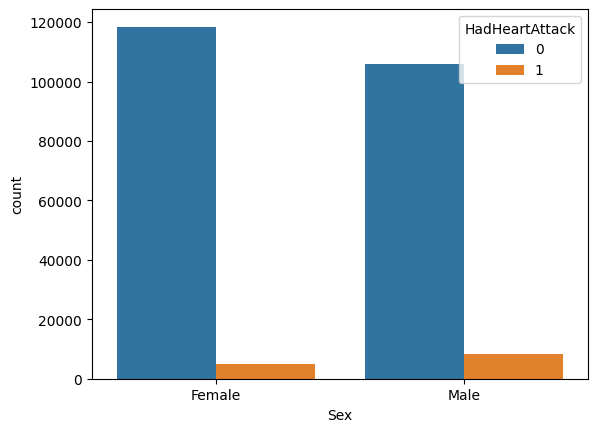

In [ ]:
sns.countplot(data=df, x='Sex', hue='HadHeartAttack')
plt.show()

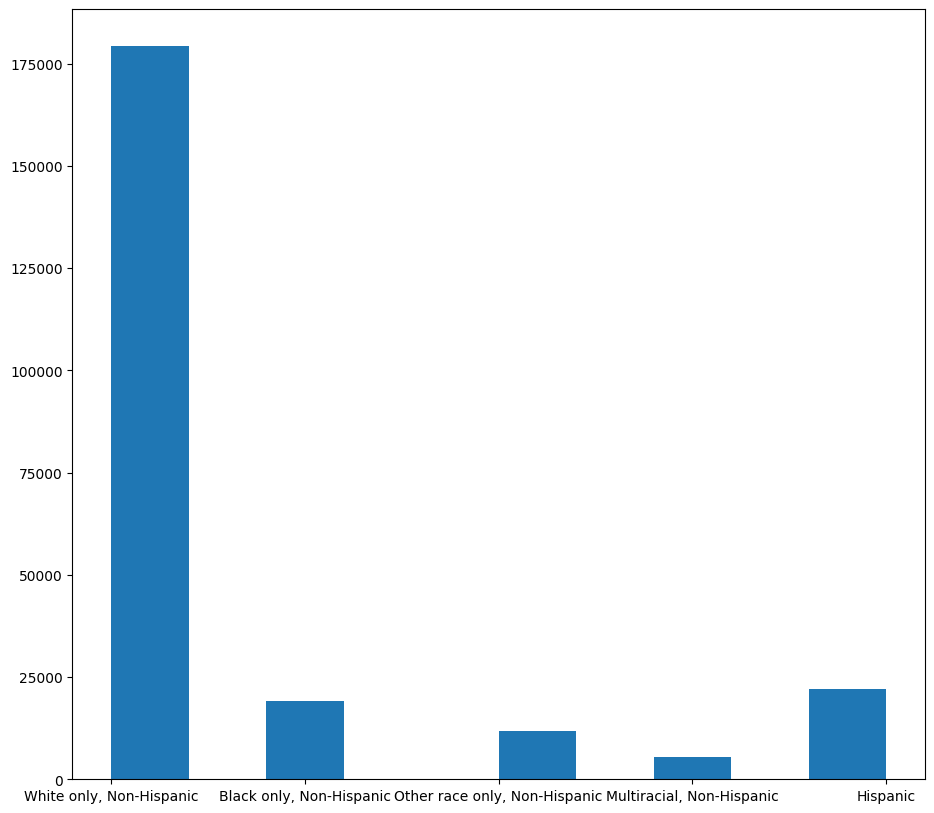

In [ ]:
plt.figure(figsize=(11,10))
plt.hist(df["RaceEthnicityCategory"])
plt.show()

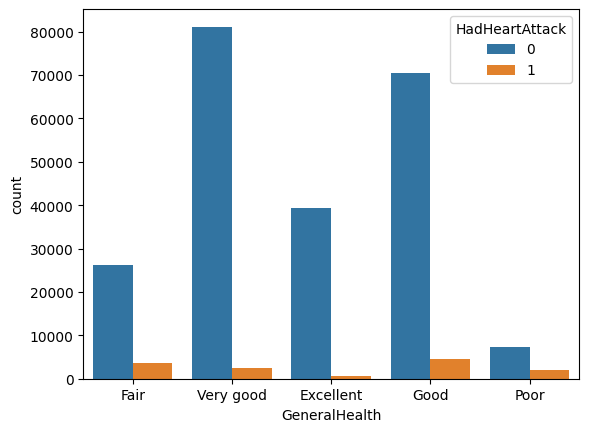

In [ ]:
sns.countplot(data=df, x='GeneralHealth', hue='HadHeartAttack')
plt.show()

## **correlation**

In [ ]:
df.head()

,ÿPatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,Never used e-cigarettes in my entire life,1,"White only, Non-Hispanic",0,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
1,2,Alabama,Female,Very good,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received Tdap",0,0
2,3,Alabama,Male,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",1,0,0,0,"Yes, received tetanus shot but not sure what type",0,0
3,4,Alabama,Male,Very good,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received tetanus shot but not sure what type",0,0
4,5,Alabama,Female,Good,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,Never used e-cigarettes in my entire life,1,"Black only, Non-Hispanic",0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0


In [ ]:
print(df["State"].unique())

['Alabama' 'Alaska' 'Arizona' 'California' 'Arkansas' 'Connecticut'
 'Colorado' 'Delaware' 'Florida' 'Georgia' 'Hawaii' 'Idaho' 'Indiana'
 'District of Columbia' 'Kansas' 'Iowa' 'Maryland' 'Minnesota' 'Montana'
 'New Jersey' 'Nebraska' 'New York' 'Ohio' 'Oklahoma' 'Texas' 'Vermont'
 'Washington' 'Utah' 'Illinois' 'West Virginia' 'Virginia' 'Massachusetts'
 'Kentucky' 'Louisiana' 'Maine' 'Wisconsin' 'Michigan' 'Mississippi'
 'Missouri' 'Nevada' 'New Hampshire' 'New Mexico' 'South Carolina'
 'North Carolina' 'North Dakota' 'Oregon' 'Pennsylvania' 'Rhode Island'
 'South Dakota' 'Tennessee' 'Wyoming' 'Guam' 'Puerto Rico'
 'Virgin Islands']


In [ ]:
print(df["Sex"].unique())

['Female' 'Male']


In [ ]:
print(df["GeneralHealth"].unique())

['Fair' 'Very good' 'Excellent' 'Good' 'Poor']


In [ ]:
df["GeneralHealth"].replace(['Poor', 'Fair', 'Good', 'Very good', 'Excellent'], [1, 2, 3, 4, 5], inplace=True)

/tmp/ipython-input-168/3406573622.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["GeneralHealth"].replace(['Poor', 'Fair', 'Good', 'Very good', 'Excellent'], [1, 2, 3, 4, 5], inplace=True)
/tmp/ipython-input-168/3406573622.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["GeneralHealth

In [ ]:
print(df["AgeCategory"].unique())

['Age 75 to 79' 'Age 65 to 69' 'Age 60 to 64' 'Age 70 to 74'
 'Age 50 to 54' 'Age 80 or older' 'Age 55 to 59' 'Age 25 to 29'
 'Age 40 to 44' 'Age 30 to 34' 'Age 35 to 39' 'Age 18 to 24'
 'Age 45 to 49']


In [ ]:
df["AgeCategory"].replace(['Age 75 to 79', 'Age 65 to 69', 'Age 60 to 64', 'Age 70 to 74',
 'Age 50 to 54', 'Age 80 or older', 'Age 55 to 59', 'Age 25 to 29',
 'Age 40 to 44', 'Age 30 to 34', 'Age 35 to 39', 'Age 18 to 24',
 'Age 45 to 49'], [77, 67, 62, 72, 52, 85, 57, 27, 42, 32, 37, 21, 47], inplace=True)

/tmp/ipython-input-168/147592969.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["AgeCategory"].replace(['Age 75 to 79', 'Age 65 to 69', 'Age 60 to 64', 'Age 70 to 74',
/tmp/ipython-input-168/147592969.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["AgeCategory"].replace(['Age 75 to 7

In [ ]:
print(df["ECigaretteUsage"].unique())

['Never used e-cigarettes in my entire life' 'Not at all (right now)'
 'Use them some days' 'Use them every day']


In [ ]:
df["ECigaretteUsage"].replace(['Never used e-cigarettes in my entire life', 'Not at all (right now)', 'Use them some days', 'Use them every day'], [0, 1, 2, 3], inplace=True)

/tmp/ipython-input-168/3314092444.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["ECigaretteUsage"].replace(['Never used e-cigarettes in my entire life', 'Not at all (right now)', 'Use them some days', 'Use them every day'], [0, 1, 2, 3], inplace=True)
/tmp/ipython-input-168/3314092444.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_o

In [ ]:
print(df["RaceEthnicityCategory"].unique())

['White only, Non-Hispanic' 'Black only, Non-Hispanic'
 'Other race only, Non-Hispanic' 'Multiracial, Non-Hispanic' 'Hispanic']


In [ ]:
print(df["TetanusLast10Tdap"].unique())

['No, did not receive any tetanus shot in the past 10 years'
 'Yes, received Tdap' 'Yes, received tetanus shot but not sure what type'
 'Yes, received tetanus shot, but not Tdap']


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['State'] = le.fit_transform(df['State'])
df['Sex'] = le.fit_transform(df['Sex'])
df['RaceEthnicityCategory'] = le.fit_transform(df['RaceEthnicityCategory'])
df['TetanusLast10Tdap'] = le.fit_transform(df['TetanusLast10Tdap'])

In [ ]:
df

,ÿPatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,0,0,2,77,1.63,84.820000,32.099998,0,1,...,0,1,4,0,0,0,1,0,0,1
1,2,0,0,4,67,1.60,71.669998,27.990000,0,0,...,0,0,4,0,0,1,1,1,0,0
2,3,0,1,5,62,1.78,71.209999,22.530001,0,0,...,0,0,4,1,0,0,0,2,0,0
3,4,0,1,4,72,1.78,95.250000,30.129999,0,0,...,0,0,4,0,0,1,1,2,0,0
4,5,0,0,3,52,1.68,78.019997,27.760000,0,0,...,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237625,237626,40,0,3,62,1.57,90.720001,36.580002,0,0,...,1,0,1,0,0,1,0,0,0,0
237626,237627,40,0,3,57,1.70,72.570000,25.059999,0,1,...,1,0,1,0,1,0,0,1,0,0
237627,237628,40,1,2,47,1.75,70.309998,22.889999,1,1,...,1,1,1,0,1,1,1,1,1,0
237628,237629,40,0,4,27,1.57,46.720001,18.840000,0,0,...,0,0,1,0,1,0,0,0,0,1


In [ ]:
print(df["TetanusLast10Tdap"].unique())

[0 1 2 3]


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ÿPatientID                 237630 non-null  int64  
 1   State                      237630 non-null  int64  
 2   Sex                        237630 non-null  int64  
 3   GeneralHealth              237630 non-null  int64  
 4   AgeCategory                237630 non-null  int64  
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [ ]:
print(df["HadDiabetes"].unique())

['Yes' 'No' 'No, pre-diabetes or borderline diabetes'
 'Yes, but only during pregnancy (female)']


In [ ]:
print(df["SmokerStatus"].unique())

['Former smoker' 'Never smoked' 'Current smoker - now smokes every day'
 'Current smoker - now smokes some days']


In [ ]:
df["SmokerStatus"].replace(['Never smoked', 'Former smoker', 'Current smoker - now smokes some days', 'Current smoker - now smokes every day'], [0, 1, 2, 3], inplace=True)

/tmp/ipython-input-168/3980494250.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["SmokerStatus"].replace(['Never smoked', 'Former smoker', 'Current smoker - now smokes some days', 'Current smoker - now smokes every day'], [0, 1, 2, 3], inplace=True)
/tmp/ipython-input-168/3980494250.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_opti

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['HadDiabetes'] = le.fit_transform(df['HadDiabetes'])

In [ ]:
df

,ÿPatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,0,0,2,77,1.63,84.820000,32.099998,0,1,...,0,1,4,0,0,0,1,0,0,1
1,2,0,0,4,67,1.60,71.669998,27.990000,0,0,...,0,0,4,0,0,1,1,1,0,0
2,3,0,1,5,62,1.78,71.209999,22.530001,0,0,...,0,0,4,1,0,0,0,2,0,0
3,4,0,1,4,72,1.78,95.250000,30.129999,0,0,...,0,0,4,0,0,1,1,2,0,0
4,5,0,0,3,52,1.68,78.019997,27.760000,0,0,...,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237625,237626,40,0,3,62,1.57,90.720001,36.580002,0,0,...,1,0,1,0,0,1,0,0,0,0
237626,237627,40,0,3,57,1.70,72.570000,25.059999,0,1,...,1,0,1,0,1,0,0,1,0,0
237627,237628,40,1,2,47,1.75,70.309998,22.889999,1,1,...,1,1,1,0,1,1,1,1,1,0
237628,237629,40,0,4,27,1.57,46.720001,18.840000,0,0,...,0,0,1,0,1,0,0,0,0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ÿPatientID                 237630 non-null  int64  
 1   State                      237630 non-null  int64  
 2   Sex                        237630 non-null  int64  
 3   GeneralHealth              237630 non-null  int64  
 4   AgeCategory                237630 non-null  int64  
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

### **oversampling-SMOTE**

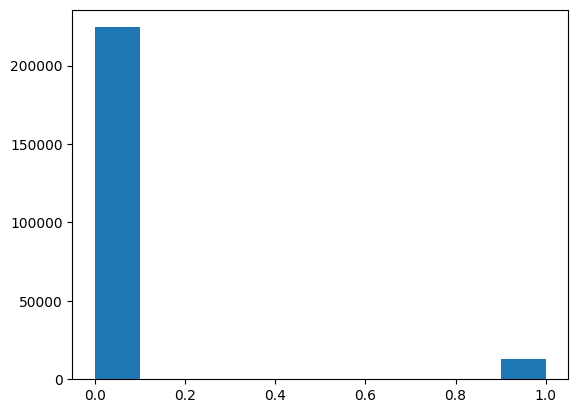

In [ ]:
plt.hist(df["HadHeartAttack"])
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

x = df.drop("HadHeartAttack", axis=1)
y = df["HadHeartAttack"]

smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(x, y)

In [ ]:
import pandas as pd

df_balanced = pd.concat([pd.DataFrame(x_resampled, columns=x.columns), pd.Series(y_resampled, name="HadHeartAttack")], axis=1)

df_balanced.head()

,ÿPatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadAngina,HadStroke,...,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos,HadHeartAttack
0,1,0,0,2,77,1.63,84.820000,32.099998,1,0,...,1,4,0,0,0,1,0,0,1,0
1,2,0,0,4,67,1.60,71.669998,27.990000,0,0,...,0,4,0,0,1,1,1,0,0,0
2,3,0,1,5,62,1.78,71.209999,22.530001,0,0,...,0,4,1,0,0,0,2,0,0,0
3,4,0,1,4,72,1.78,95.250000,30.129999,0,0,...,0,4,0,0,1,1,2,0,0,0
4,5,0,0,3,52,1.68,78.019997,27.760000,0,0,...,1,0,0,0,1,0,0,0,0,0


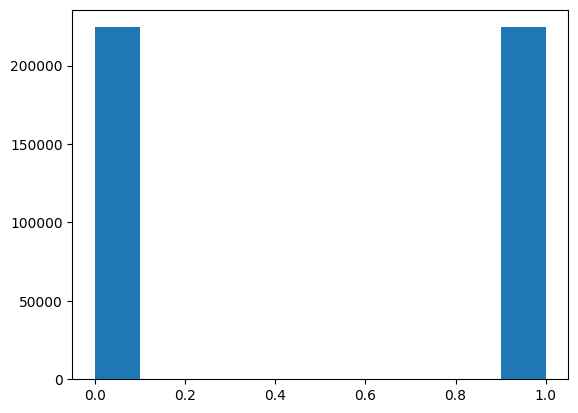

In [ ]:
plt.hist(df_balanced["HadHeartAttack"])
plt.show()

In [ ]:
df=df_balanced

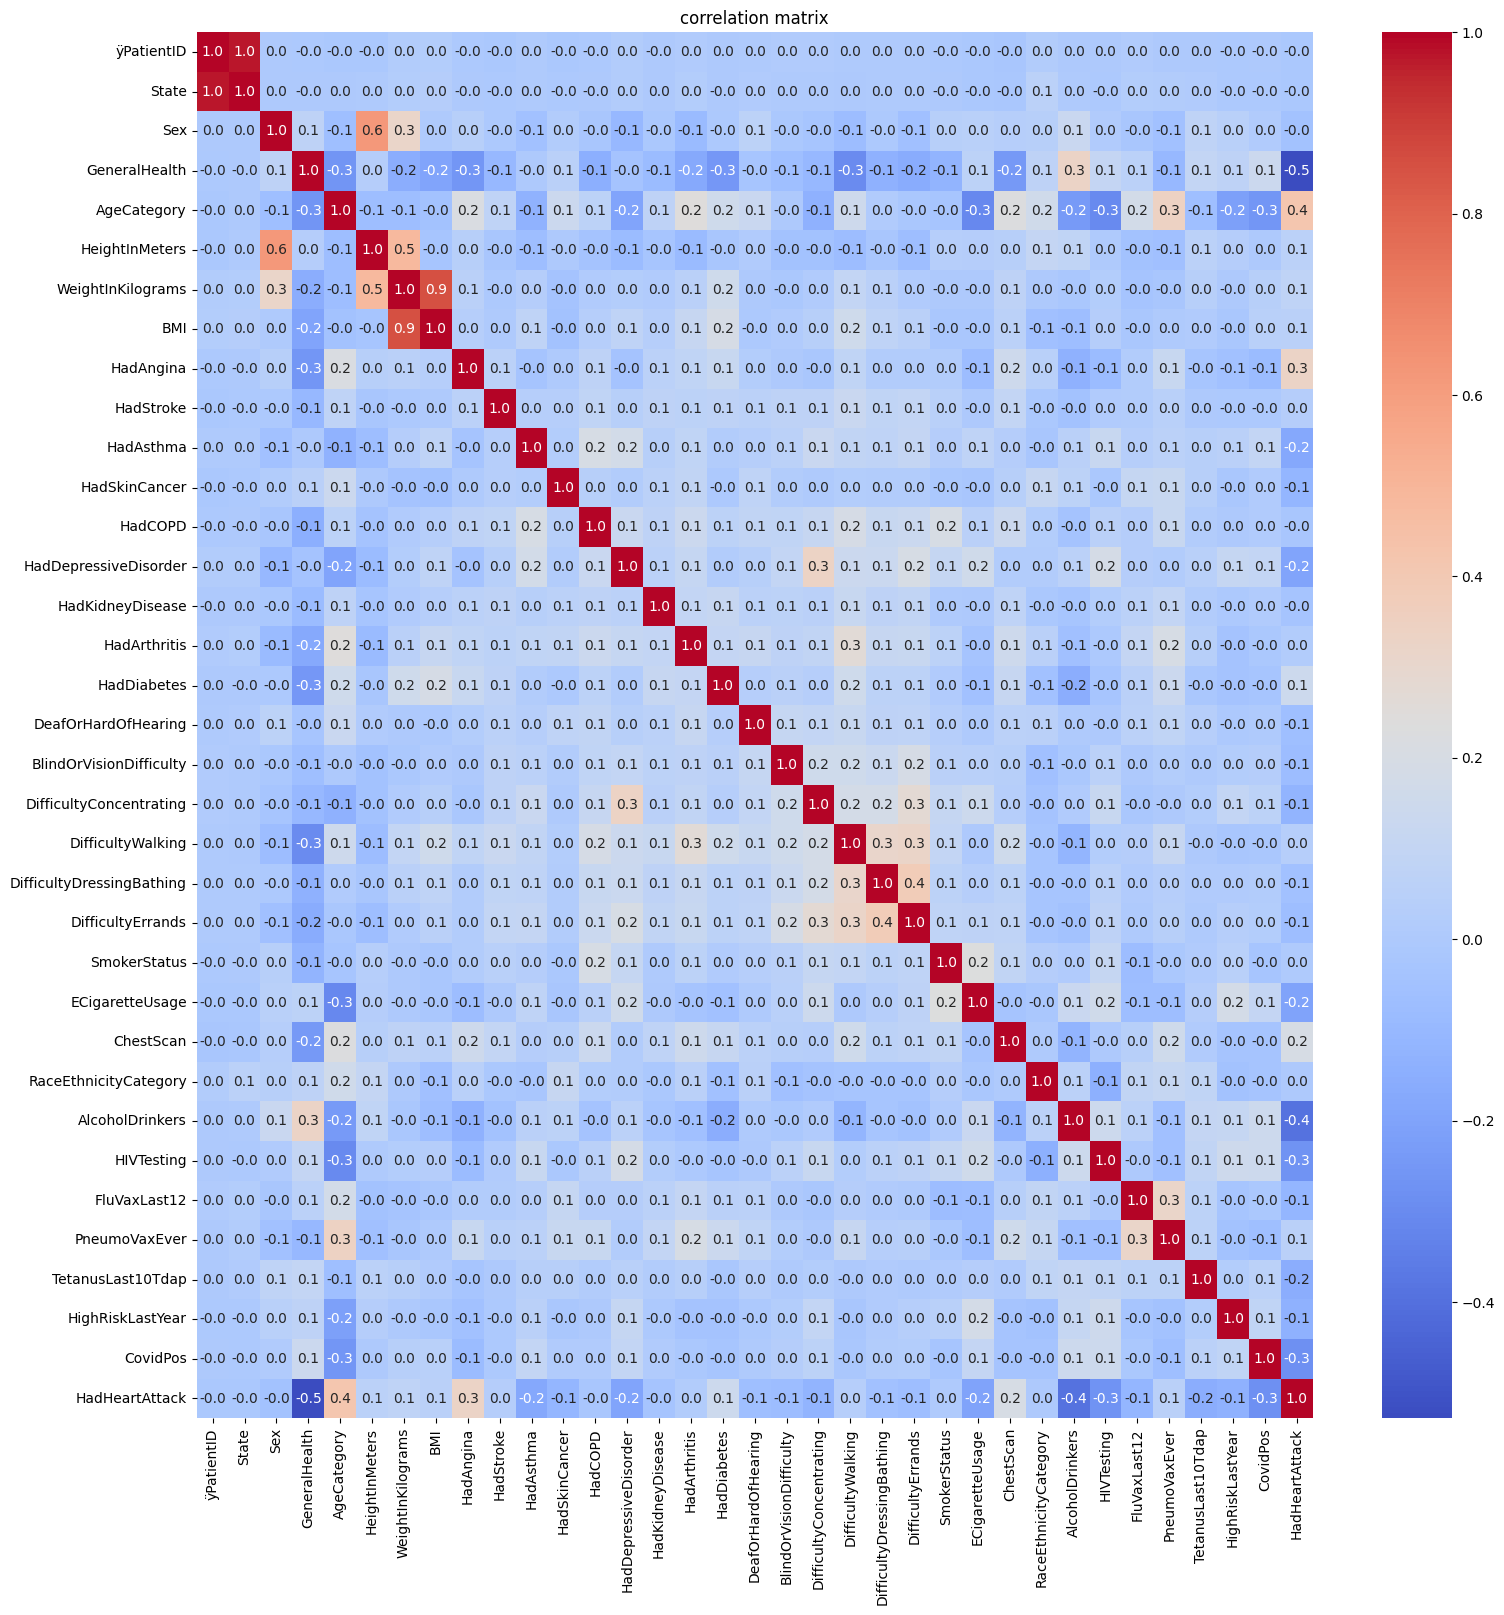

In [ ]:
plt.figure(figsize= (18,18))

corr_matrix = df.corr()


sns.heatmap(corr_matrix, annot=True, fmt='0.01f', cmap='coolwarm')
plt.title('correlation matrix')
plt.show()

In [ ]:
df.drop(["WeightInKilograms"], axis=1, inplace=True)

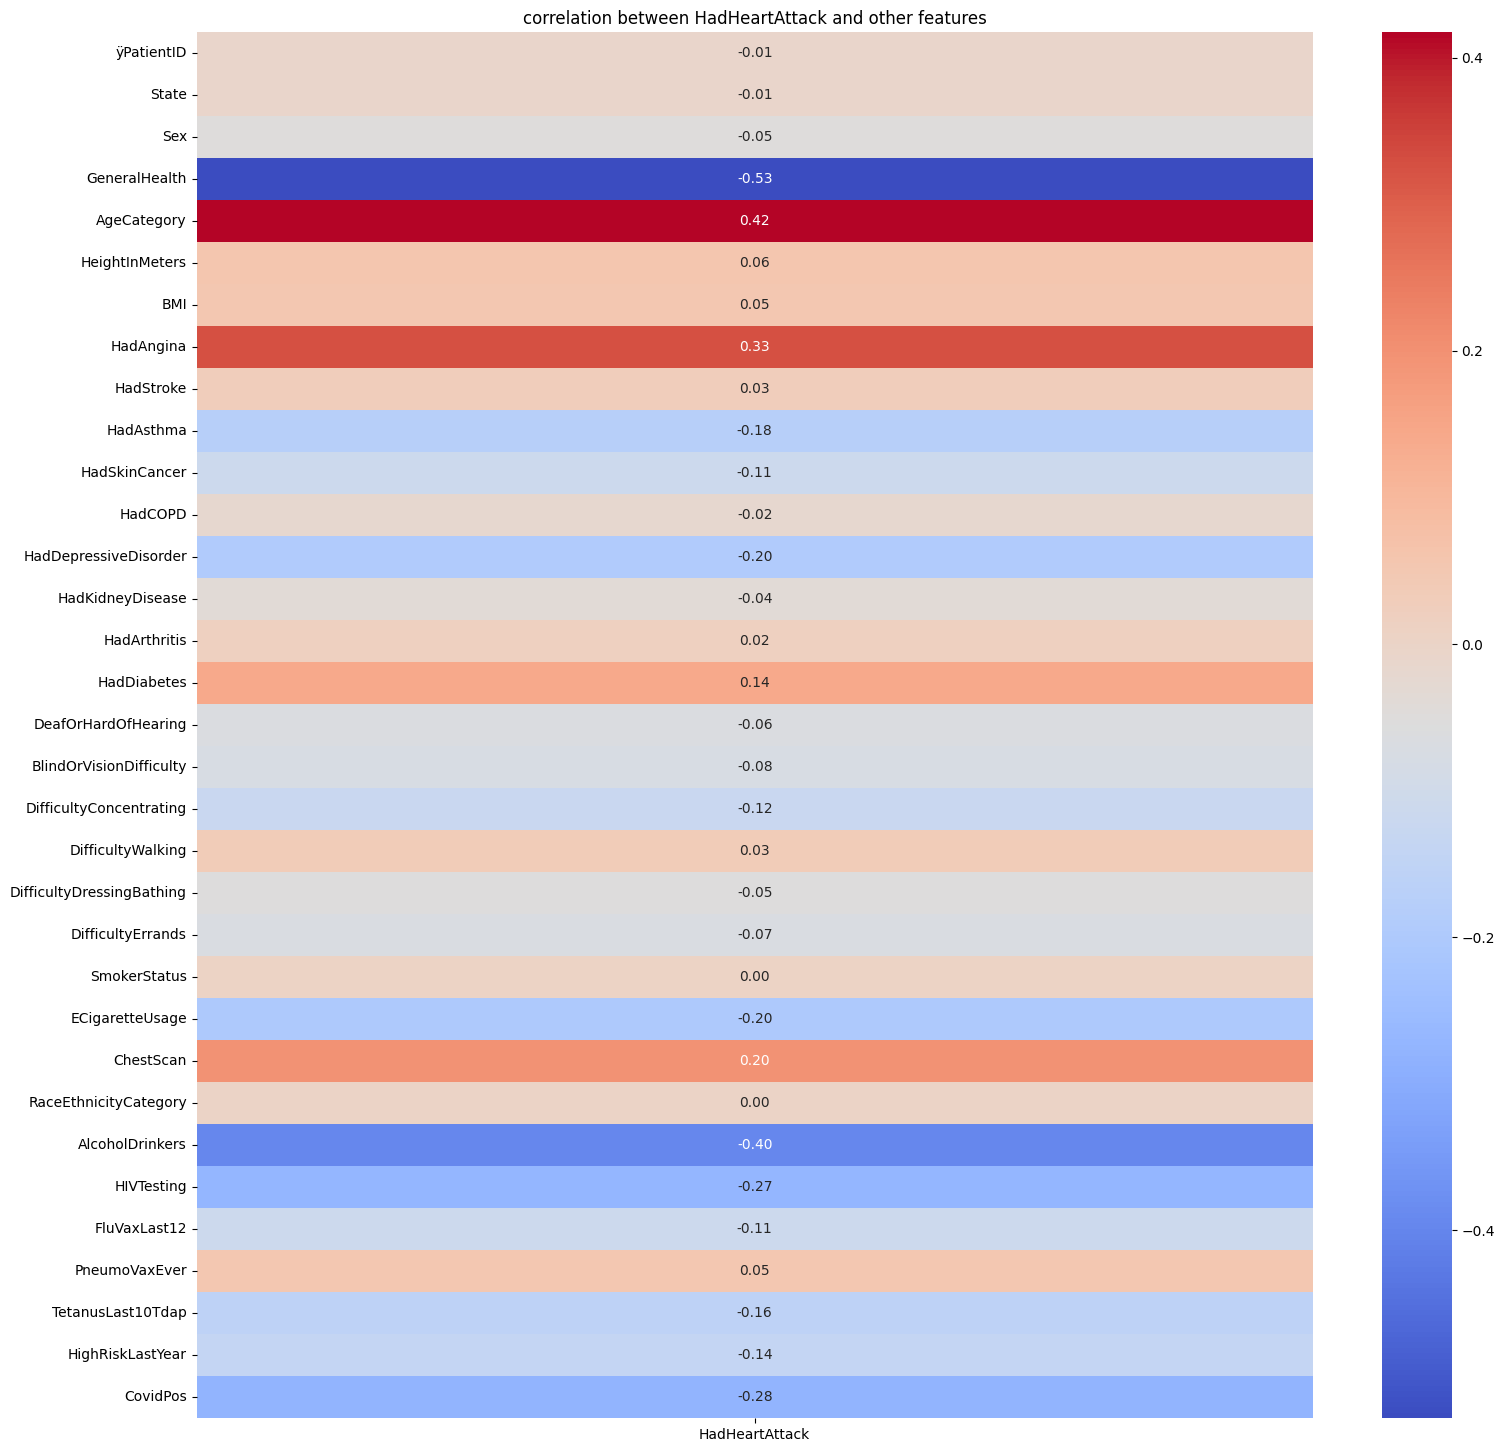

In [ ]:
plt.figure(figsize= (18,18))

HadHeartAttack_corr = df.corr()['HadHeartAttack']

HadHeartAttack_corr = HadHeartAttack_corr.drop('HadHeartAttack')

sns.heatmap(HadHeartAttack_corr.to_frame(), annot=True, fmt='0.2f', cmap='coolwarm', cbar=True, annot_kws={'size':10})

plt.title('correlation between HadHeartAttack and other features')
plt.show()

In [ ]:
df.drop(['ÿPatientID', 'State', 'Sex', 'HeightInMeters', 'BMI', 'HadAsthma', 'HadSkinCancer', 'HadDepressiveDisorder', 'BlindOrVisionDifficulty', 'DifficultyConcentrating', 'DifficultyDressingBathing',
         'DifficultyErrands', 'SmokerStatus', 'ECigaretteUsage', 'RaceEthnicityCategory', 'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'TetanusLast10Tdap', 'HighRiskLastYear', 'CovidPos', 'HadCOPD', 'HadKidneyDisease',
         'HadArthritis', 'HadDiabetes', 'DeafOrHardOfHearing', 'PneumoVaxEver'], axis=1, inplace=True)

In [ ]:
df

,GeneralHealth,AgeCategory,HadAngina,HadStroke,DifficultyWalking,ChestScan,HadHeartAttack
0,2,77,1,0,1,1,0
1,4,67,0,0,0,0,0
2,5,62,0,0,0,0,0
3,4,72,0,0,0,0,0
4,3,52,0,0,0,1,0
...,...,...,...,...,...,...,...
448853,2,62,0,0,0,1,1
448854,1,62,1,0,0,0,1
448855,2,66,0,0,0,1,1
448856,2,56,1,1,0,1,1


## **outlier checking and removing**

<Axes: >

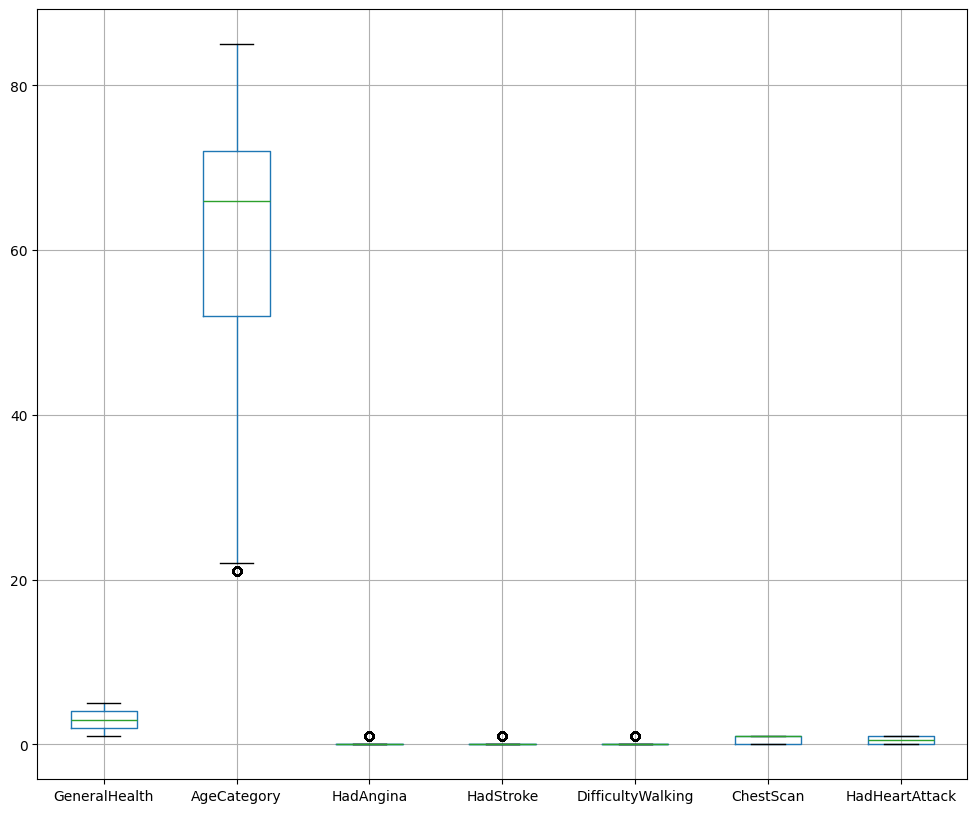

In [ ]:
plt.figure(figsize= (12,10))

df.boxplot()

In [ ]:
def remove_outliers_iqr(df, exclude_column):
  for col in df.columns:

    if col == exclude_column:
      continue

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
  return df

df_cleaned = remove_outliers_iqr(df, exclude_column='HadHeartAttack')
df = df_cleaned

In [ ]:
df.shape

(308060, 7)

## **Data scaling**

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

features = ['GeneralHealth', 'AgeCategory', 'HadAngina', 'HadStroke', 'DifficultyWalking', 'ChestScan']

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[features])

scaled_df = pd.DataFrame(scaled_data, columns=features)

In [ ]:
df

,GeneralHealth,AgeCategory,HadAngina,HadStroke,DifficultyWalking,ChestScan,HadHeartAttack
1,4,67,0,0,0,0,0
2,5,62,0,0,0,0,0
3,4,72,0,0,0,0,0
4,3,52,0,0,0,1,0
6,3,72,0,0,0,1,0
...,...,...,...,...,...,...,...
448850,2,73,0,0,0,1,1
448851,1,57,0,0,0,1,1
448853,2,62,0,0,0,1,1
448855,2,66,0,0,0,1,1


## **train test split**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

x = df[['GeneralHealth', 'AgeCategory', 'HadAngina', 'HadStroke', 'DifficultyWalking', 'ChestScan']]
y = df['HadHeartAttack']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

model = LogisticRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy: 0.2f}')

Baseline model accuracy:  0.80


In [ ]:
df.head(50)

,GeneralHealth,AgeCategory,HadAngina,HadStroke,DifficultyWalking,ChestScan,HadHeartAttack
1,4,67,0,0,0,0,0
2,5,62,0,0,0,0,0
3,4,72,0,0,0,0,0
4,3,52,0,0,0,1,0
6,3,72,0,0,0,1,0
9,3,85,0,0,0,0,0
10,3,57,0,0,0,0,0
11,3,27,0,0,0,0,0
12,3,52,0,0,0,1,0
13,5,62,0,0,0,0,0


In [ ]:
model.predict([[3, 85, 0, 0, 0, 0]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1])

## **Kfold**

In [ ]:
from sklearn.model_selection import KFold

x = df.drop("HadHeartAttack", axis=1)
y = df["HadHeartAttack"]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = LogisticRegression()


best_accuracy = 0
best_fold = -1

best_x_train = None
best_y_train = None
best_x_test = None
best_y_test = None
best_y_pred = None


for fold, (train_index, test_index) in enumerate(kf.split(x), 1):
  x_train, x_test = x.iloc[train_index], x.iloc[test_index]
  y_train, y_test = y.iloc[train_index], y.iloc[test_index]

  model.fit(x_train,y_train)

  y_pred = model.predict(x_test)
  acc = accuracy_score(y_test, y_pred)
  print(f"Fold {fold} Accuracy: {acc}")


  if acc > best_accuracy:
     best_accuracy = acc
     best_fold = fold
     best_x_train = x_train
     best_y_train = y_train
     best_x_test = x_test
     best_y_test = y_test
     best_y_pred = y_pred

print(f"\n Best Fold: {best_fold} with Accuracy: {best_accuracy}")

Fold 1 Accuracy: 0.7977017464130364
Fold 2 Accuracy: 0.7998604168019217
Fold 3 Accuracy: 0.7996331883399338
Fold 4 Accuracy: 0.7997954943842108
Fold 5 Accuracy: 0.7963221450366812

 Best Fold: 2 with Accuracy: 0.7998604168019217


In [ ]:
model = LogisticRegression()
model.fit(best_x_train, best_y_train)
model.score(best_x_test, best_y_test)

0.7998604168019217

## **Decision Tree Algorithm**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(best_x_train, best_y_train)

best_y_pred = model.predict(best_x_test)

accuracy = accuracy_score(best_y_test, best_y_pred)

print(f"Baseline model accuracy: {accuracy: 0.2f}")

Baseline model accuracy:  0.89


## **Support Vector Machine**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler

In [ ]:
pipeline = Pipeline([('scaler', StandardScaler()),('model', LinearSVC(random_state=42, max_iter=5000))])

pipeline.fit(best_x_train, best_y_train)

y_pred = pipeline.predict(best_x_test)

print("Accuracy:", accuracy_score(best_y_test, best_y_pred))

Accuracy: 0.8901350386288386


## **Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
model = RandomForestClassifier()

model.fit(best_x_train, best_y_train)
best_y_pred = model.predict(best_x_test)

accuracy = accuracy_score(best_y_test, best_y_pred)

print(f"Baseline model accuracy: {accuracy: 0.2f}")

Baseline model accuracy:  0.89


## **DL**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.metrics import Accuracy

In [ ]:
model = Sequential([Dense(256, input_shape=(6,), activation='relu'),
                    Dense(128, activation='relu'),
                    Dense(64, activation='relu'),
                    Dense(32, activation='relu'),
                    Dense(1, activation='sigmoid')])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'] )

In [ ]:
model.fit(best_x_train, best_y_train, epochs=100,batch_size=32)

Epoch 1/100
7702/7702 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - accuracy: 0.7805 - loss: 0.4641
Epoch 2/100
7702/7702 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - accuracy: 0.7972 - loss: 0.4384
Epoch 3/100
7702/7702 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step - accuracy: 0.7949 - loss: 0.4399
Epoch 4/100
7702/7702 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.7976 - loss: 0.4363
Epoch 5/100
7702/7702 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.7991 - loss: 0.4354
Epoch 6/100
7702/7702 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - accuracy: 0.8029 - loss: 0.4316
Epoch 7/100
7702/7702 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.8048 - loss: 0.4280
Epoch 8/100
7702/7702 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - accuracy: 0.8045 - loss: 0.4274
Epoch 9/100
7702/7702 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.8049 - loss: 0.4271
Epoch 10/100
7702/7702 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - accuracy: 0.8055 - loss: 0.4257
Epoch 11/100
7702/7702 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.8048 - loss: 0.4280
Epoch 12

In [ ]:
test_loss, test_acc = model.evaluate(best_x_test, best_y_test)

print(f'\nTest Accuracy: {test_acc}')

1926/1926 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8271 - loss: 0.3730

Test Accuracy: 0.818590521812439


In [ ]:
model = RandomForestClassifier()

model.fit(best_x_train, best_y_train)
best_y_pred = model.predict(best_x_test)

accuracy = accuracy_score(best_y_test, best_y_pred)

print(f"Baseline model accuracy: {accuracy: 0.2f}")

Baseline model accuracy:  0.89


In [ ]:
import pickle
with open("Heartattack_forst_model.pkl","wb") as file:
  pickle.dump(model,file)

In [ ]:
with open("/content/Heartattack_forst_model.pkl","rb") as file:
  load_model=pickle.load(file)

In [ ]:
best_y_pred = load_model.predict(best_x_test)

accuracy = accuracy_score(best_y_test, best_y_pred)

print(f"Baseline model accuracy: {accuracy: 0.2f}")

Baseline model accuracy:  0.89


## **conclusion:**

This project focused on developing a heart attack prediction model using machine learning techniques. One of the key challenges was the imbalanced dataset, which was successfully overcome using resampling methods to ensure balanced class distribution and improve model fairness.

Several classification models were trained and evaluated, and Random Forest achieved the highest accuracy of 89%, showing strong predictive performance. The final optimized model was saved in pickle format, making it ready for deployment and real-time heart attack risk prediction.